# Wykład #2

## 1. Metryki jakości danych

**Metryki jakości danych** to wskaźniki służące do oceny, czy dane są **wiarygodne, kompletne i użyteczne** do analizy, raportowania lub trenowania modeli (np. w uczeniu maszynowym). Pomagają sprawdzić, czy dane nadają się do wykorzystania i gdzie występują problemy.

Można je traktować jak **“miary zdrowia danych”**

**Najważniejsze metryki jakości danych**

### 1.1 Kompletność (Completeness)

Sprawdza, czy w danych **nie brakuje wartości**.

**Przykład:**  
W bazie klientów pole „email” jest wypełnione tylko w 80% rekordów.
Metryka kompletności = **80%**.

### 1.2 Dokładność (Accuracy)

Ocena, czy dane **odzwierciedlają rzeczywistość**.

**Przykład:**  
Adres klienta w bazie zgadza się z rzeczywistym adresem w 95% przypadków.

### 1.3 Spójność (Consistency)

Sprawdza, czy dane są **jednakowe w różnych systemach lub tabelach**.

**Przykład:**  
Klient w systemie CRM ma datę urodzenia **1990-05-10**, a w systemie płatności **1991-05-10** → brak spójności.

### 1.4 Aktualność (Timeliness / Freshness)

Mierzy, czy dane są **aktualne i dostarczane na czas**.

**Przykład:**  
Dane sprzedażowe powinny być aktualizowane codziennie, ale są aktualizowane co 3 dni.

### 1.5 Unikalność (Uniqueness)

Sprawdza, czy w danych **nie ma duplikatów**.

**Przykład:**  
Ten sam klient pojawia się w bazie **3 razy** z różnymi ID.

### 1.6 Poprawność formatów (Validity)

Sprawdza, czy dane **spełniają określone reguły lub formaty**.

**Przykład:**

* email ma format `nazwa@domena.com`
* wiek nie może być ujemny

#### Przykład prostego raportu jakości danych

| Metryka     | Wynik |
| ----------- | ----- |
| Kompletność | 92%   |
| Dokładność  | 95%   |
| Spójność    | 89%   |
| Aktualność  | 97%   |
| Unikalność  | 93%   |

Taki raport pokazuje, **gdzie dane wymagają poprawy**.

**W praktyce metryki jakości danych są bardzo ważne w:**

* analityce danych
* systemach BI
* projektach AI / ML
* hurtowniach danych

---

Poszczególne metryki składają się na ogólną miarę jakości danych, dla której można przyjąć bardziej ogólne określenie jakości wskaźników poprzez **KPI (Key Performance Indicators), czyli kluczowe wskaźniki efektywności**.
Wynik zostanie wykorzystany do oceny stanu i jakości źródeł danych. Może być również wykorzystany do weryfikacji zgodności z wymogami dotyczącymi jakości danych uzgodnionymi w umowie dotyczącej danych zawartej między producentem danych, a konsumentem danych. 

Nie jest to więc sztywna lista metryk, którą można przyłożyć do dowolnych danych, a raczej zbiór metod, które należy zaimplementować dla danego zbioru czy źródła danych.

Dodatkowo, takie metryki są przeliczane za każdym razem, kiedy napływają nowe dane, które mają być celem dalszego przetwarzania.

Wskaźniki jakości danych powinny być również obliczane na poziomie fizycznym, mierząc KPI każdego:

* źródła danych,
* schematu bazy danych,
* tabeli,
* kolumny.

Mierzenie ogólnej wartości metryki jakości danych jest dość proste, zgodnie ze wzorem:

$$Ogólna\ jakość\ danych\ (np.\ KPI) = \frac{liczba\ testów\ pozytywnych\ dla\ danych}{liczba\ wszystkich\ testów} * 100\%$$

Istnieją również wariacje takich miar, gdzie każdy test danych może skończyć się wynikiem innym niż tylko pozytywny/negatywny. Może to być dodatkowo ostrzeżenie, błąd krytyczny, które również można włączyć do metryki zarówno po stronie mianownika lub licznika (np. wszystkie pozytywne + ostrzeżenia / wszystkie pozytywne + ostrzeżenia + błędy + błędy krytyczne).

**Przykład w języku Python.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# przygotowanie danych testowych
data = {
    'ID': list(range(1,11)),
    'AGE': [34, 21, -1, 18, 29, 55, 43, 32, 25, 50],
    'HEIGHT': [None, 154, 178, 188, 155, None, 192, 182, 177, 160],
    'DATE_CREATED': ''.join([date * 5 for date in ['2026-02-01,','2026-03-01,']]).split(',')[:-1]
}

In [11]:
df = pd.DataFrame(data)

In [13]:
df.head(10)

,ID,AGE,HEIGHT,DATE_CREATED
0,1,34,NaN,2026-02-01
1,2,21,154.0,2026-02-01
2,3,-1,178.0,2026-02-01
3,4,18,188.0,2026-02-01
4,5,29,155.0,2026-02-01
5,6,55,NaN,2026-03-01
6,7,43,192.0,2026-03-01
7,8,32,182.0,2026-03-01
8,9,25,177.0,2026-03-01
9,10,50,160.0,2026-03-01


Na początek najprostsze testy, np. kompletności.

In [34]:
df.style.highlight_null(color='red')

,ID,AGE,HEIGHT,DATE_CREATED
0,1,34,nan,2026-02-01
1,2,21,154.000000,2026-02-01
2,3,-1,178.000000,2026-02-01
3,4,18,188.000000,2026-02-01
4,5,29,155.000000,2026-02-01
5,6,55,nan,2026-03-01
6,7,43,192.000000,2026-03-01
7,8,32,182.000000,2026-03-01
8,9,25,177.000000,2026-03-01
9,10,50,160.000000,2026-03-01


In [40]:
# test kompletności dla całego zbioru danych
df_nan_map = df.isna()
completeness = 1 - (np.sum(df_nan_map.values) / (df_nan_map.shape[0] * df_nan_map.shape[1]))

In [41]:
print(f"Kompletność dla całego zbioru danych wynosi: {completeness * 100:.2f} %")

Kompletność dla całego zbioru danych wynosi: 95.00 %


In [47]:
# kompletność dla każdej cechy
for feature in df.columns:
    print(f"Kompletność dla cechy {feature} wynosi: {(1 - (np.sum(df[feature].isna()) / df.shape[0])) * 100 :.2f} %")

Kompletność dla cechy ID wynosi: 100.00 %
Kompletność dla cechy AGE wynosi: 100.00 %
Kompletność dla cechy HEIGHT wynosi: 80.00 %
Kompletność dla cechy DATE_CREATED wynosi: 100.00 %


In [53]:
# lub tak
df.apply(lambda x: f"{(1 - np.sum(x.isna()) / df.shape[0]) * 100:.2f} %")

ID              100.00 %
AGE             100.00 %
HEIGHT           80.00 %
DATE_CREATED    100.00 %
dtype: object

In [74]:
# można też nie wprost poprzez dodanie negacji (~) do warunku logicznego
df.apply(lambda x: f"{np.sum(~x.isna()) / df.shape[0] * 100:.2f} %")

ID              100.00 %
AGE             100.00 %
HEIGHT           80.00 %
DATE_CREATED    100.00 %
dtype: object

In [69]:
# można do takich testów dodać również koleny wymiar, np. czas, gdzie testy wykonywane są dla ustalonych interwałów 
# np. w miarę przyrostu danych,
# najpierw konwersja na typ datetime, z którego łatwiej wyciągać składowe daty (i czasu)
df['DATE_CREATED'] = pd.to_datetime(df['DATE_CREATED'])

df.groupby(df['DATE_CREATED'].dt.month.rename('miesiąc')).agg(lambda x: f"{(1 - np.sum(x.isna()) / df.shape[0]) * 100:.2f} %")

,ID,AGE,HEIGHT,DATE_CREATED
miesiąc,,,,
2,100.00 %,100.00 %,90.00 %,100.00 %
3,100.00 %,100.00 %,90.00 %,100.00 %


Można również sprowadzić te wyniki do macierzy binarnej, gdzie wartości < 100 % to test, który się nie powiódł (ang. failed) lub jeżeli wartość to 100 % to test, który przeszedł (ang. passed).

In [80]:
bin_matrix = df.groupby(df['DATE_CREATED'].dt.month.rename('miesiąc')).agg(lambda x: (1 - np.sum(x.isna()) / df.shape[0]) * 100) == 100
bin_matrix

,ID,AGE,HEIGHT,DATE_CREATED
miesiąc,,,,
2,True,True,False,True
3,True,True,False,True


In [92]:
kpi_completeness = np.sum(bin_matrix.values) / len(bin_matrix.values.flat)
kpi_completeness

np.float64(0.75)

Teraz test, który możemy podciągnąć pod cechę **poprawności (ang. validity)**. Test przeprowadzony zostanie dla cechy **AGE** i będzie wykonywał proste sprawdzenie czy wartość jest w odpowiednim przedziale. Przyjmijmy, że jest to wartość między 1 a 126.

In [75]:
# dla jednej cechy jest to dość łatwe, sprawdzmy zawieranie się wartości w przedziale
f"Poprawność danych dla AGE: {np.sum(df.AGE.apply(lambda x : 0 < x < 127)) / df.shape[0] * 100: .2f} %"

'Poprawność danych dla AGE:  90.00 %'

**Ostateczne KPI** można więc wyliczyć ze stosunku testów, które się powiodły, względem wszystkich przeprowadzonych testów. Mamy więc dwa scenariusze:
* sccnariusz 1:
  * kompletność dla każdej cechy bez podziału na miesiące: 4 testy (4 kolumny po jednej wartości z testu)
  * poprawność dla cechy AGE
  * **razem testów: 5**
  * **testów, które przeszły: 3 (3/4 dla kompletności, 0/1 z poprawności)**
  * **Globalne KPI: 3/5 = 60%**
* scenariusz 2:
  * kompletność dla każdej cechy z podziałem na miesiące: tu 8 wartości (po 4 dla każdego z dwóch miesięcy)
  * poprawność dla cechy AGE
  * **razem testów: 9**
  * **testów, które przeszły: 6 (6/8 dla kompletności, 0/1 z poprawności)**
  * **Globalne KPI: 6/9 ~ 67%**

**Podsumowanie**

Metryki jakości danych mogą być wykorzystane do zastosowania technik preprocessingu danych w celu np. obsługi braków, odrzucenia wartości błędnych lub ponownego wykonania pomiarów. Mogą również być wykorzystane do monitorowania stanu danych po fazie preprocessingu w celu podjęcia automatycznych kroków zareagowania na ten incydent (wstrzymanie treningu modelu, wymiana czujników, sprawdzenie działania przepływów danych, itp.).

Cel stosowania kontroli metryk jakości danych:

* **potoki danych (ETL/ELT)**: monitorowanie potoków danych podczas przenoszenia i transformacji w celu wczesnego wykrywania błędów,
* **trening modeli AI/ML**: zapewnienie dokładności i wiarygodności danych wykorzystywanych w sztucznej inteligencji,
* **zgodność z przepisami**: zapewnienie zgodności danych z normami w celu uniknięcia kar,
* **porównywanie wyników**: śledzenie jakości danych w czasie w celu oceny działań mających na celu poprawę.


## 2. Wybrane rozkłady danych oraz ich badanie

### 2.1 Czym są rozkłady danych oraz jak się je bada?

**Czym są rozkłady danych?**

**Rozkład danych** opisuje **jak często pojawiają się różne wartości w zbiorze danych**. Pokazuje więc **strukturę danych** – czy wartości są skupione w jednym miejscu, rozproszone, symetryczne albo mają długie „ogony”.

Można powiedzieć, że rozkład odpowiada na pytanie:

> **Jak rozłożone są wartości w zbiorze danych?**

Rozkłady są jednym z podstawowych pojęć w statystyce i w Data Science, ponieważ pozwalają zrozumieć dane **zanim zaczniemy budować modele lub wyciągać wnioski**.

W pierwszym wykładzie poruszony został już temat percentyli, kwantyli oraz miar rozrzutu danych, które są ściśle powiązane z zagadnieniem rozkładu danych. Zaczniemy od kilku sposobów analizy rozkładu danych na przykładach, a następnie przejdziemy do omówienia wybranych rozkładów danych.


Przykładowe dane wykorzystane w fragmentach kodu pochodzą z https://www.kaggle.com/datasets/mafaqbhatti/top-100-cities-by-population-2026.

In [2]:
df_cities = pd.read_csv('top_100_cities/Top 100 Worlds Largest Cities.csv')
df_cities.head()

,Rank,City,Country,Population (Est.),Area (sq km)
0,1,Tokyo,Japan,"37,115,000","8,231"
1,2,Delhi,India,"35,500,000","2,344"
2,3,Shanghai,China,"31,050,000","4,333"
3,4,Dhaka,Bangladesh,"25,360,000","2,570"
4,5,Sao Paulo,Brazil,"23,170,000","3,649"


In [7]:
df_cities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Rank               100 non-null    int64 
 1   City               100 non-null    object
 2   Country            100 non-null    object
 3   Population (Est.)  100 non-null    object
 4   Area (sq km)       100 non-null    object
dtypes: int64(1), object(4)
memory usage: 4.0+ KB


In [3]:
# potrzebne jest wykonanie małego preprocessingu danych i konwersji typów
# dla kolumn Population oraz Area
df_cities['Population (Est.)'] = df_cities['Population (Est.)'].str.replace(',','')
df_cities['Area (sq km)'] = df_cities['Area (sq km)'].str.replace(',','')

In [4]:
df_cities['Population (Est.)'] = df_cities['Population (Est.)'].astype(np.float64)
df_cities['Area (sq km)'] = df_cities['Area (sq km)'].astype(np.int32)

In [6]:
df_cities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               100 non-null    int64  
 1   City               100 non-null    object 
 2   Country            100 non-null    object 
 3   Population (Est.)  100 non-null    float64
 4   Area (sq km)       100 non-null    int32  
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 3.6+ KB


### 2.2 Badanie rozkładów danych

Najpopularniejszymi metodami badania rozkładów danych są:
* **histogramy**,
* **wykresy pudełkowe (ang. boxplot)**,
* **tablice częstości/liczności**,
* **wykresy gęstości rozkładu**.

#### Zacznijmy od przykładowej **tablicy częstości**.

Tablica częśtości dla cechy dzieli ją na przedziały o tej samej odległości danych i zlicza wartości, które w tych przedziałach się znajdują. Poniżej przykład.

In [20]:
# podział danych na 10 równych zakresów i wypisanie zakresu dla każdej obserwacji
bin_population = pd.cut(df_cities['Population (Est.)'], 10)
# zliczenie liczby wartości w każdym zakresie
bin_population.value_counts()

Population (Est.)
(4347265.0, 7653500.0]      44
(7653500.0, 10927000.0]     24
(10927000.0, 14200500.0]    10
(14200500.0, 17474000.0]     8
(17474000.0, 20747500.0]     5
(20747500.0, 24021000.0]     5
(33841500.0, 37115000.0]     2
(24021000.0, 27294500.0]     1
(30568000.0, 33841500.0]     1
(27294500.0, 30568000.0]     0
Name: count, dtype: int64

Wyliczenie percentyli, możemy również wykonać dla wielu ich wartości jednocześnie. Możeliwe jest również podzielenie danych na przedziały, które wynikają z wartości percentyli, a nie przedziałów rozłożónych równo.

In [28]:
# wypisanie wartości granicznych dla zadanych percentyli
df_cities['Population (Est.)'].quantile([0.05, 0.25, 0.75, 0.95])

0.05     4577000.0
0.25     5415000.0
0.75    12652500.0
0.95    23079750.0
Name: Population (Est.), dtype: float64

In [36]:
# podział danych ze względu na przynależność do danego percentyla
perc = [0.05, 0.25, 0.75, 0.95]
pd.qcut(df_cities['Population (Est.)'], perc)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
95    NaN
96    NaN
97    NaN
98    NaN
99    NaN
Name: Population (Est.), Length: 100, dtype: category
Categories (3, interval[float64, right]): [(4576999.999, 5415000.0] < (5415000.0, 12652500.0] < (12652500.0, 23079750.0]]

In [40]:
pop_qcut = pd.qcut(df_cities['Population (Est.)'], perc)

In [42]:
# niewiele z tego wynika
pop_qcut

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
95    NaN
96    NaN
97    NaN
98    NaN
99    NaN
Name: Population (Est.), Length: 100, dtype: category
Categories (3, interval[float64, right]): [(4576999.999, 5415000.0] < (5415000.0, 12652500.0] < (12652500.0, 23079750.0]]

In [43]:
# jednak podobnie jak w poprzednich przypadkach zwrócona została seria z przynależnościami do przedziałów
# jednak sposób wyświetlania danych przez Jupyter notebook w przypadkach, gdzie cała seria nie mieści się
# w komórce (a są limity wyświetlanych wierzszy) wyświetla 5 pierwszych i ostatnoch wartości, które tutaj
# otrzymują etykiety NaN gdyż wartości te znajdują się poniżej 5-go percentyla oraz powyżej 95-go percentyla
# tu widać, że jest 5 unikalnych wartości w kolumnie
pop_qcut.unique()

[NaN, (12652500.0, 23079750.0], (5415000.0, 12652500.0], (4576999.999, 5415000.0]]
Categories (3, interval[float64, right]): [(4576999.999, 5415000.0] < (5415000.0, 12652500.0] < (12652500.0, 23079750.0]]

#### Kolejny przykład przedstawia **histogram**, który jest metodą wizualizacji tablicy częstości.

<Axes: ylabel='Frequency'>

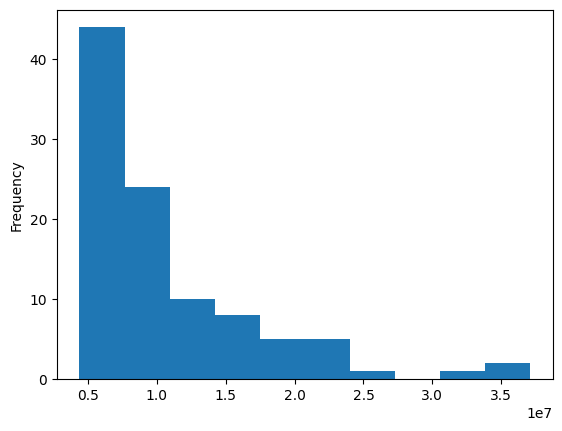

In [5]:
# domyślny podział to 10 tzw. koszyków (ang. bins)
df_cities['Population (Est.)'].plot.hist()

<Axes: ylabel='Frequency'>

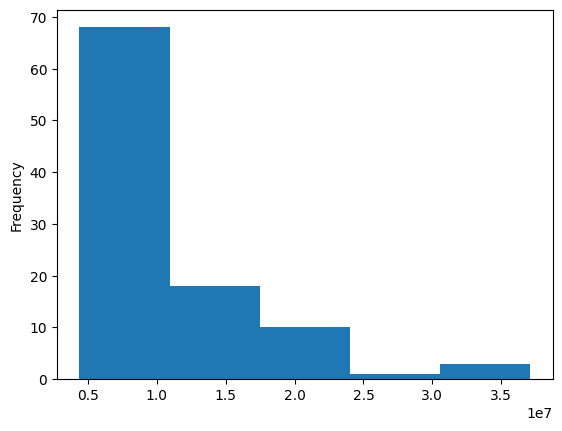

In [6]:
# możemy to jednak dowolnie zmieniać
df_cities['Population (Est.)'].plot.hist(bins=5)

<Axes: xlabel='Population (Est.)', ylabel='Count'>

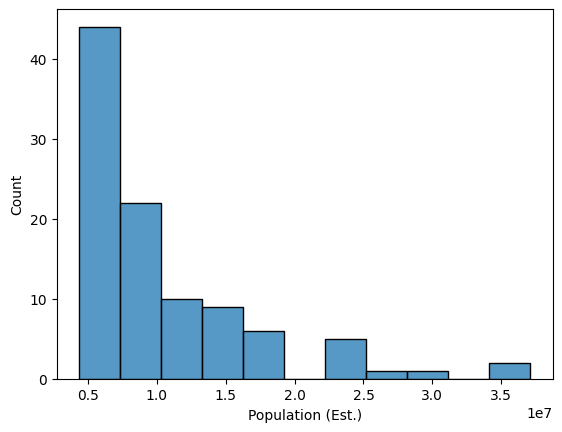

In [7]:
# w bibliotece seabonr (bazującej na matplotlib) wygląda to dość podobnie
sns.histplot(df_cities['Population (Est.)'])

Bezpośrenio powiązany z histogramem jest wykres gęstości rozkładu, który jest niejako wygładzonym histogramem. Wyliczany jest poprzez estymator jądrowy gęstości (ang. kernel density estimate, KDE).

Więcej o KDE: https://pl.wikipedia.org/wiki/Estymator_j%C4%85drowy_g%C4%99sto%C5%9Bci

Poniżej przykład wykresów.


<Axes: ylabel='Density'>

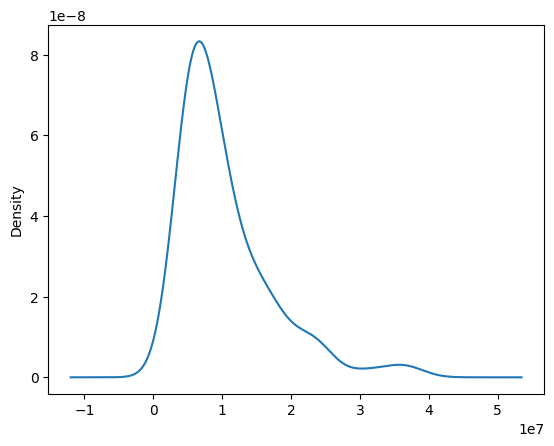

In [6]:
df_cities['Population (Est.)'].plot.kde()

<Axes: ylabel='Density'>

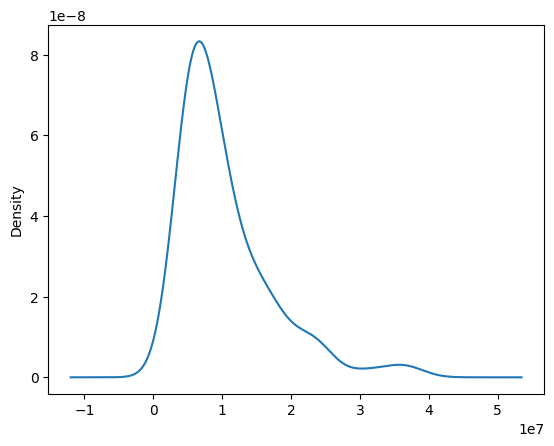

In [7]:
# to samo co powyżej
df_cities['Population (Est.)'].plot.density()

<Axes: xlabel='Population (Est.)', ylabel='Count'>

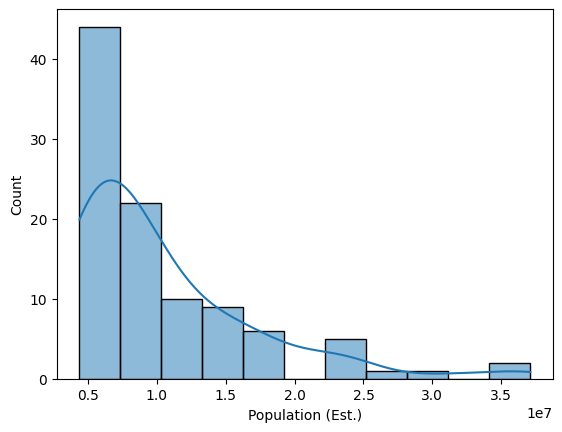

In [12]:
# w przypadku biblioteki seaborn jest to łatwiejsze
sns.histplot(df_cities['Population (Est.)'], kde=True)

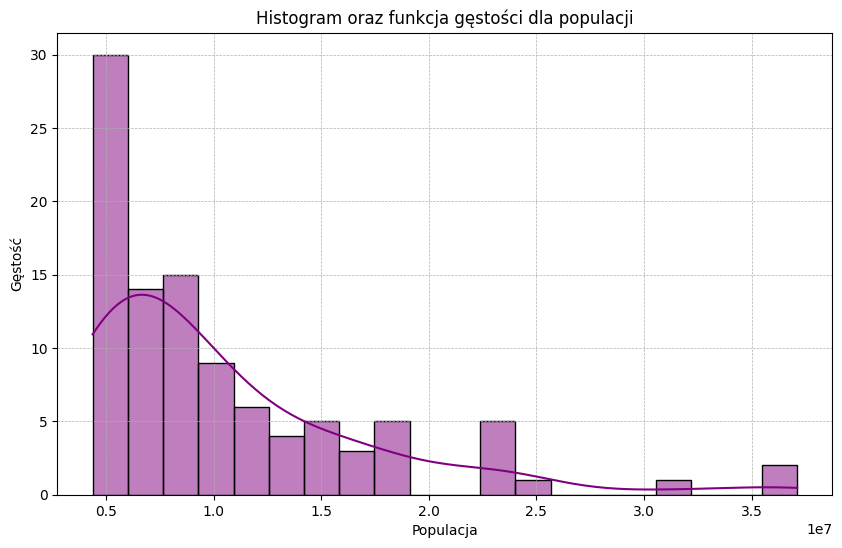

In [13]:
# można oczywiście dodać do wykresu nieco więcej informacji (tu 20 przedziałów histogramu)
plt.figure(figsize=(10, 6))
sns.histplot(df_cities['Population (Est.)'], bins=20, kde=True, color='purple', edgecolor='black')
plt.title('Histogram oraz funkcja gęstości dla populacji')
plt.xlabel('Populacja')
plt.ylabel('Gęstość')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

#### Kolejny przykład to wykorzystanie **wykresów pudełkowych**.

Wykres został zaproponowany przez **Johna Tukeya w książce "Explanatory Data Analysis"**, wydanej w 1997 roku.

Poniżej grafika, która wyjaśnia składowe wykresu.

![Wykres pudełkowy prosty](./wykres-pudełkowy.png)

![Wykres pudełkowy złożony](./wykres-pudełkowy2-1.png)

_źródło: https://www.statystyka-zadania.pl/wykres-pudelkowy/_

Mediana, kwartyle i wartość minimalna oraz maksymalna nie stanowią dla nas już żadnej tajemnicy.

Wykres numer dwa prezentuje również możliwe pojawienie się wartości odstających, które są wyliczane z przedstawionym również na wykladzie numer 1 rozstępem międzyćwiartkowym (ang. Interqunatile Range, IQR).

Wartości dostające znajdują się po obu stronach pudełka (bardziej ogólnie - rozkładu danych) i są wyliczane zgodnie ze wzorami:

* $$IQR = Q3 - Q1$$
* $$ Outlier_{lower} = Q1 - 1.5 * IQR$$
* $$ Outlier_{upper} = Q3 + 1.5 * IQR$$

In [62]:
# możemy to wilczyć zanim wyświetlimy wykres
q1 = df_cities['Population (Est.)'].quantile([0.25]).values[0]
q3 = df_cities['Population (Est.)'].quantile([0.75]).values[0]
iqr = q3 - q1
out_lower = q1 - 1.5 * iqr
out_upper = q3 + 1.5 * iqr

In [70]:
q1, q3, iqr, out_lower, out_upper

(np.float64(5415000.0),
 np.float64(12652500.0),
 np.float64(7237500.0),
 np.float64(-5441250.0),
 np.float64(23508750.0))

Widzimy też w wynikach, że dla cechy `Population` wartości odstających po lewej stronie danych nie będzie, musiałaby to być wartość ujemna.

Text(0, 0.5, 'Populacja w milionach')

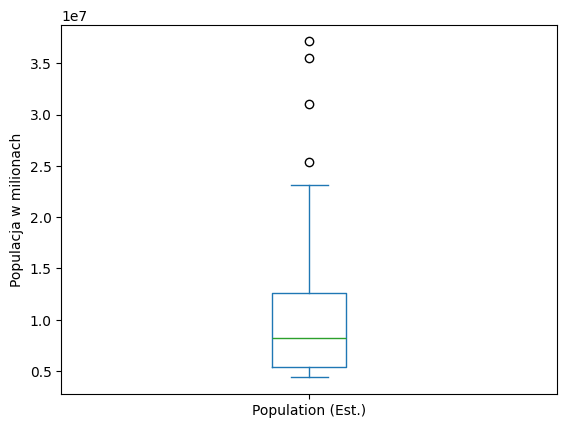

In [54]:
ax = df_cities['Population (Est.)'].plot.box();
ax.set_ylabel("Populacja w milionach")

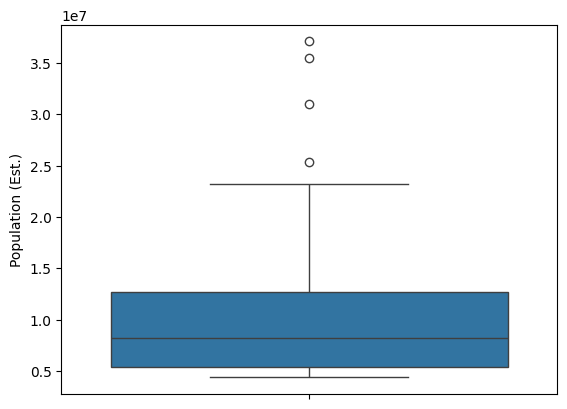

In [51]:
sns.boxplot(df_cities['Population (Est.)']);

**Podsumowanie**

Analiza rozkładów jest ważnym czynnikiem eksploracyjnej analizy danych (EDA) pozwalającym na "poznanie" danych. Rozkłady mogą nam dostarczyć takich informacji jak to czy w danych występują wartości odstające, czy dane charakteryzują się skośnością, jak bardzo dane są zgrupowane wokół średniej/mediany, co może na tym etapie wskazać potencjalne kolejne działania w procesie przetwarzania danych, np. w celu przygotowania ich dla modeli ML czy tworzeniu reprezentatywnych próbek danych z całej populacji.
Porównanie rozkładów danych dla kilku próbek (z tych samych lub różnych populacji) może być przydatne w wielu zadaniach. Możemy dowiedzieć się z jakim prawdopodobnieństwem obserwujemy próbkę danych z określonej populacji, możemy dowiedzieć się czy charakterystyka (np. z wykresu pudełkowego) wygląda tak samo dla danych pogrupowanych np. po kategorii, kraju, wieku czy innych cechach.

## 3. Najczęstsze rozkłady danych

### 3.1 Rozkład normalny (Gaussowski)

To najbardziej znany rozkład spośród rozkładów dla wartości ciągłych. Ma charakterystyczny **kształt dzwonu**.

![](normal_distribution.webp)

_źródło: https://www.geeksforgeeks.org/python/python-normal-distribution-in-statistics/_

Reguła Trzech Sigm dla rozkładu normalnego $N(μ,σ)$ mówi nam że w przedziale $[μ–3σ,μ+3σ]$ zawiera się 99.7 % wszystkich obserwacji. Ta metoda jest również jedną z metod wyznaczania wartości odstających. Wartość jest określana jako odstająca, jeżeli bezwzględna różnica między tą wartością a wartością oczekiwaną (średnią) jest większa niż 3 * sigma. Czyli jeżeli wartość leży od wartości środkowej rozkładu dalej niż 3 odległości odchylenia standardowego.
Poprzez grecką literę `μ` (czyt. mju/mi) oznaczamy wartość średnią z danych, a poprzez `σ` (sigma) oznaczamy odchylenie standardowe.

Istnieje też rozkład normalny nazywany **standardowym normalnym**, w którym **średnia = 0** oraz **odchylenie standardowe = 1**.


**Cechy:**

* symetryczny
* większość wartości jest blisko średniej
* im dalej od średniej, tym mniej obserwacji

Przykłady z rzeczywistości:

* wzrost ludzi
* wyniki testów IQ
* błędy pomiarowe

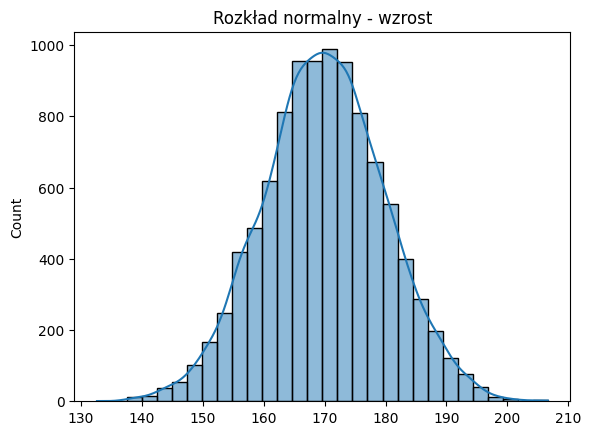

In [23]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(loc=170, scale=10, size=10000)

sns.histplot(data, bins=30, kde=True)
plt.title("Rozkład normalny - wzrost")
plt.show()

**Interpretacja:**

* średni wzrost ≈ 170 cm
* większość wartości między 160 a 180 cm.

Wykres, który widzimy jest wykresem `z próby`. Oznacza to, że mamy dane takie jak średni wzrost (170) oraz odchylenie standardowe (10), które może wynikać z pomiarów dla całej populacji, jednak w tym przypadku wydaje się to niemożliwe. 

Oznacza to, że dane, które zostały wygenerowane poprzez **próbkowanie** (ang. sampling) są pewnym przybliżeniem danych z populacji. 

Im więcej próbek wygenerujemy, tym bardziej wykres będzie zbliżony do wykresu dla populacji (czyli wzorca). Można to zaobserwować zwiększając wielkość próby.

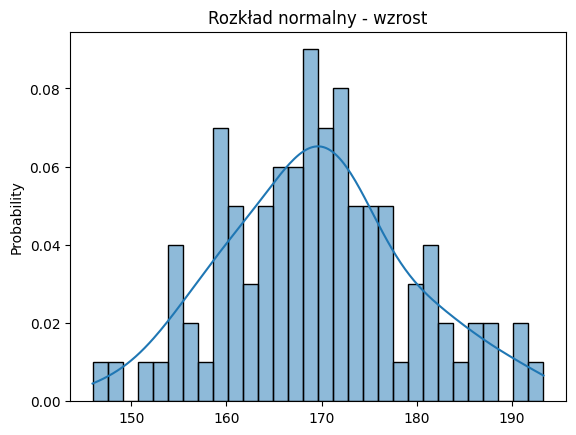

samples = 100, μ = 169.44911931146493, σ = 9.684646600146372


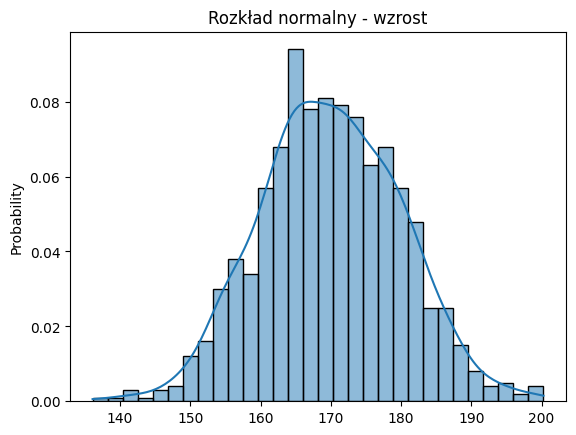

samples = 1000, μ = 169.97029488590846, σ = 9.948818029846112


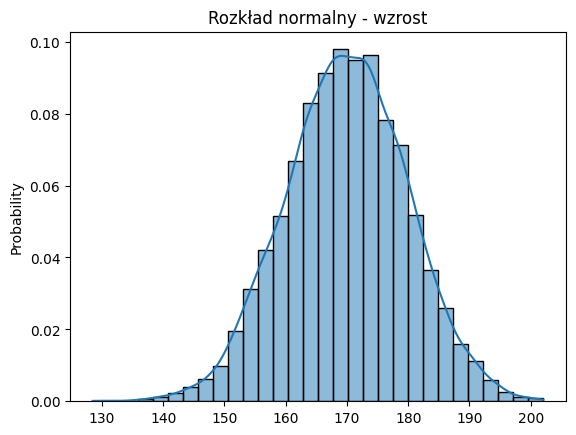

samples = 10000, μ = 169.89902906774904, σ = 9.91384593587728


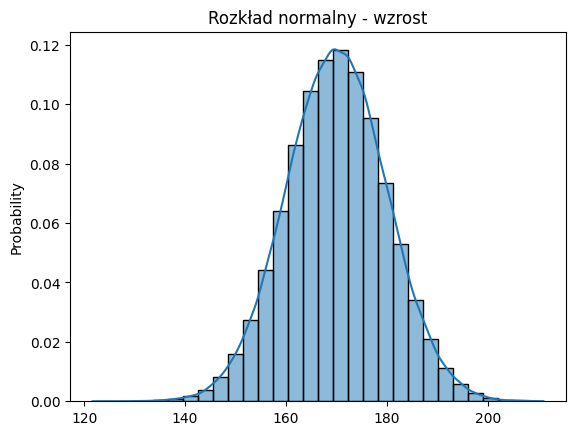

samples = 100000, μ = 170.02884629196146, σ = 9.962308090472188


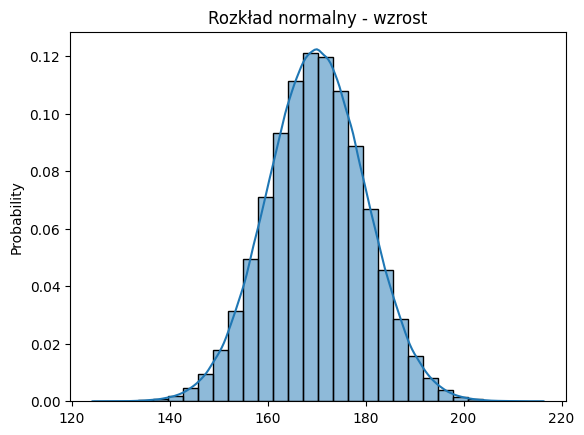

samples = 1000000, μ = 169.9977006033031, σ = 10.004821226325758


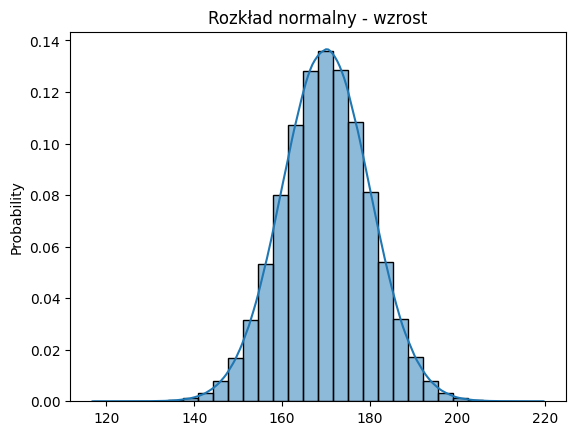

samples = 10000000, μ = 169.998476079464, σ = 9.997656968376212


In [29]:
samples = [10**n for n in range(2, 8)]

for sample in samples:
    data = np.random.normal(loc=170, scale=10, size=sample)
    
    sns.histplot(data, bins=30, kde=True, stat='probability')
    plt.title("Rozkład normalny - wzrost")
    plt.show()
    print(f"samples = {sample}, μ = {np.mean(data)}, σ = {np.std(data)}")

To zjawisko nazywane jest **centralnym twierdzeniem granicznym** (ang. central limit theorem) i mówi ono, że **średnie dla prób będą przypominać rozkład normalny**, nawet jeżeli rozkład z populacji nie jest rozkładem normalnym.

W tym miejscu można również wspomnieć o innym ważnym prawie, który towarzyszy rozkładom prawdopodobieństwa oraz próbom z populacji. Za Wikipedią:

> Prawa wielkich liczb – seria twierdzeń matematycznych (jedno z tzw. twierdzeń granicznych) opisujących związek między liczbą wykonywanych doświadczeń a faktycznym prawdopodobieństwem wystąpienia > zdarzenia, którego te doświadczenia dotyczą. Najprostsza postać prawa wielkich liczb to prawo Bernoulliego orzekające, że:

> _**„Z prawdopodobieństwem dowolnie bliskim 1 można się spodziewać, iż przy dostatecznie wielkiej liczbie prób częstość danego zdarzenia losowego będzie się dowolnie mało różniła od jego prawdopodobieństwa.”**_

> Ta postać jest historycznie najwcześniejsza; sformułował ją szwajcarski matematyk Jakob Bernoulli w 1713 roku w książce Ars Conjectandi. Nazwał to twierdzenie „złotym”, inni matematycy – twierdzeniem Bernoulliego, a Siméon Denis Poisson w 1835 roku – prawem wielkich liczb; ta ostatnia nazwa stała się najczęstszą.

_źródło: https://pl.wikipedia.org/wiki/Prawo_wielkich_liczb_

### 3.2 Rozkład jednostajny (ang. uniform distribution)

Każda wartość ma **takie samo prawdopodobieństwo**.

**Przykład:**

* wynik rzutu idealną kostką
* liczba losowa z generatora

Wynik: histogram jest **płaski**.

Ten rodzaj rozkładu jest dobrym przykładem do zaprezentowania rozkładu "natury rzeczy" (czyli populacji) i porównania go z rozkładem z próby. Tu możemy sprawdzić **czy prawo wielkich liczb** faktycznie działa.

Przyjmijmy, że ta "natura rzeczy" polega na losowaniu wartości dyskretnych z przedziału [1, 10]. Wylosowanie każdej liczby jest równie prawdopodobne. Rozkład a priori będzie więc jednostajny i wonosił 1/10 dla każdej wartości.

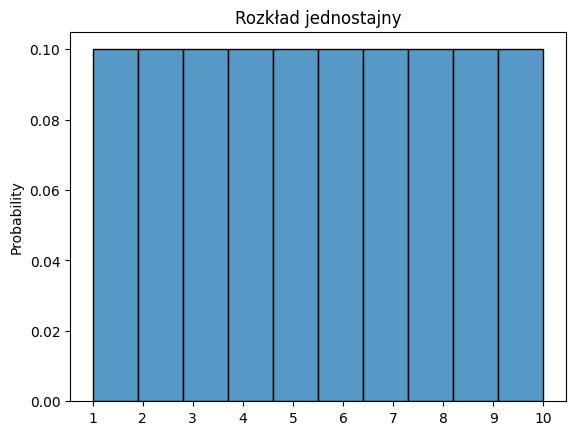

In [37]:
data_a_priori = list(range(1, 11))
sns.histplot(data_a_priori, bins=10, stat='probability')
plt.xticks(list(range(1, 11)))
plt.title("Rozkład jednostajny")
plt.show()

Uruchomimy teraz generator liczb pseudolosowych, który przy takich samych założeniach wylosuje 10 liczb z tego przedziału, i zaprezentuje ich rozkład na histogramie.

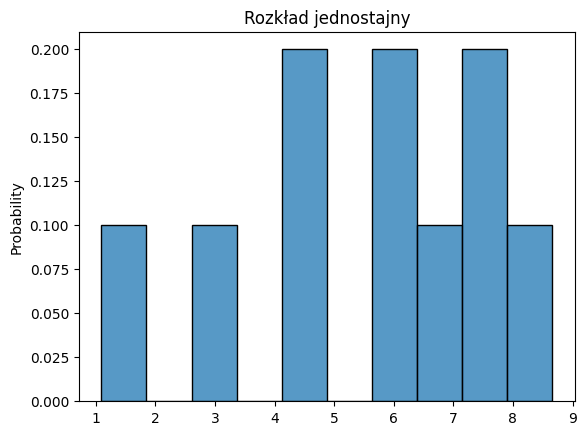

In [40]:
data = np.random.uniform(1, 10, 10)
sns.histplot(data, bins=10, stat='probability')
plt.title("Rozkład jednostajny")
plt.show()

**Wniosek**

Przy każdym uruchomieniu powyższego przykładu rozkład będzie się zmieniał, ale istnieje dość małe prawdopodobieństo, że będzie wyglądał jak ten "bazowy".

Zwiększmy liczbę próbek.

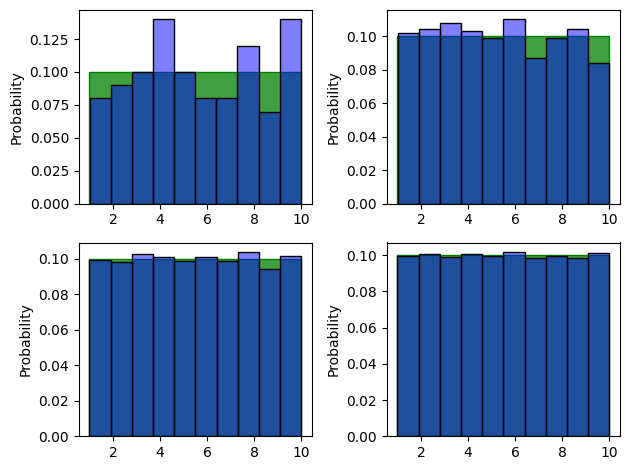

In [82]:
fig, axs = plt.subplots(2, 2)

samples = [100, 1000, 10000, 100000]

for ax, sample in zip(axs.flat, samples):
    _data = np.random.uniform(1, 10, sample)
    sns.histplot(list(range(1,11)), bins=10, stat='probability', color='green', ax=ax, element='step')
    sns.histplot(data=_data, bins=10, stat='probability', color='blue', alpha=0.5, ax=ax)
plt.tight_layout()

**Wniosek**

Widać wyraźnie, że wraz ze wzrostem liczby próbek, rozkład zbliża się do rozkładu a priori.

### 3.3 Rozkład dwumianowy (binarny)

Jest to rozkład z grupy rozkładów dyskretnych, który określa rozkład wartości dla **prób niezależnych**, z których każda może zakończyć się tylko jedenm z dwóch wyników. Ten rozkład nazywany jest również **rozkładem Bernoulliego**. Często określa się go również rozkładem liczby sukcesów w danej (n) liczbie prób niezależnych. Za sukces najczęściej przyjmuje się wartość 1 (przeciwieństwo 0) przy rozpatrywaniu go jako problemu binarnego.

Przykładem takiego eksperymentu może być rzut monetą (często określaną jako uczciwa przy jednakowym rozkładzie prawdopodobieństwa dla orła i reszki wynoszącym 0.5). 

**Zastosowanie:**

* Testy A/B - czy użytkownik **kliknie reklamę czy nie**
* Medycyna - czy pacjent **zareaguje na lek**
* Kontrola jakości - czy produkt jest **wadliwy czy poprawny**
* Systemy IT - czy serwer **zwróci błąd czy sukces**


Parametrami dla takiego rozkładu jest zazwyczaj wielkość próby (n) oraz prawdopodobieństwo sukcecu (p). 
W Pythonie możemy to wyliczyć chociażby tak jak pokazano w poniższych przykładach.

**Dokumentacja obiektu `scipy.stats.binom.`**: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html

In [89]:
from scipy import stats

# co to oznacza?
stats.binom.pmf(k=1, n=2, p=0.5)

np.float64(0.5000000000000002)

Powyższy wynik oznacza prawdopodobieństwo jednego sukcesu (parametr `k`) przy `n=2` próbach z prawdopodobieństwem sukcesu `p=0.5`.

In [91]:
# prawdopodobieństwo dwóch sukcesów przy dwóch próbach z równym prawdopodobieństwem porażki i sukcesu
stats.binom.pmf(k=2, n=2, p=0.5)

np.float64(0.25)

Przyjmijmy, że nasz eksperyment to 10-cio krotny rzut monetą. Chcemy dowiedzieć się jak wygląda rozkład sukcesów dla tekiego eksperymentu.

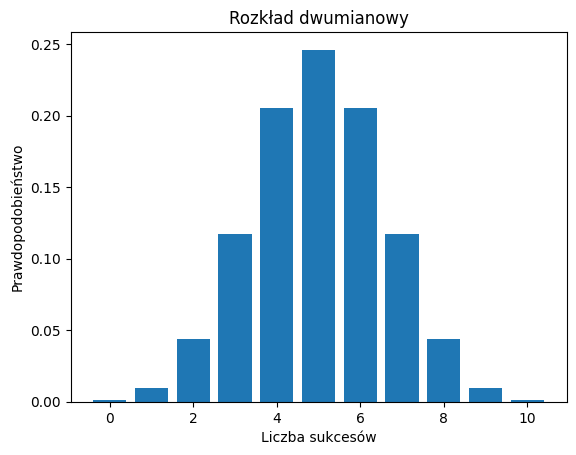

In [92]:
# wizualizacja rozkładu

n = 10
p = 0.5

x = np.arange(0, n+1)
y = stats.binom.pmf(x, n, p)

plt.bar(x, y)
plt.xlabel("Liczba sukcesów")
plt.ylabel("Prawdopodobieństwo")
plt.title("Rozkład dwumianowy")
plt.show()

**Pytanie:**

> Jakie jest prawdopodobieństwo, że wypadnie **dokładnie 6 orłów**?

To właśnie opisuje rozkład dwumianowy.

**Wzór**

Prawdopodobieństwo obliczamy ze wzoru:

$$ \huge P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

gdzie:

* (n) – liczba prób
* (k) – liczba sukcesów
* (p) – prawdopodobieństwo sukcesu
* ($\binom{n}{k}$) – liczba kombinacji.

**Odpowiedź:**

* najwyższe prawdopodobieństwo jest około **5 sukcesów**.

**Przykład z analizy danych - jakość produkcji**

Załóżmy:

* fabryka produkuje części
* **5% produktów jest wadliwych**

Parametry:

* (n = 20) (sprawdzamy 20 produktów)
* (p = 0.05) (wadliwy produkt)

**Pytanie:**

> Jakie jest prawdopodobieństwo, że **2 produkty będą wadliwe**?

In [96]:
# odpowiedź
prob = stats.binom.pmf(2, 20, 0.05)
prob

np.float64(0.18867680126765404)

**Symulacja rozkładu**

Możemy też **zasymulować eksperyment**.

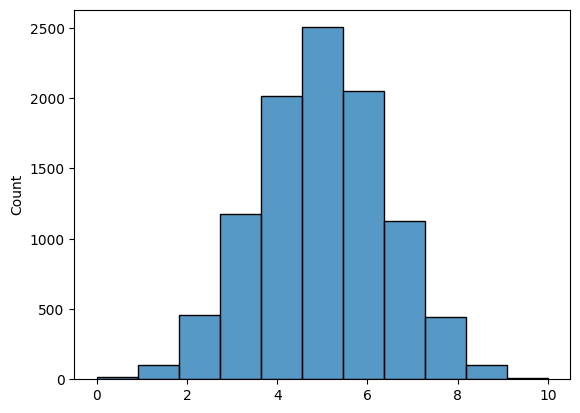

In [98]:
n = 10
p = 0.5

samples = np.random.binomial(n, p, 10000)

sns.histplot(samples, bins=11)
plt.show()

To pokazuje, jak rozkład wygląda **empirycznie**.

### 3.4 Rozkład Chi kwadrat

**Czym jest rozkład chi-kwadrat?**

Chi-squared Distribution

**Rozkład chi-kwadrat (χ²)** to rozkład prawdopodobieństwa używany głównie w **testach statystycznych** do sprawdzania:

* czy dane pasują do oczekiwanego modelu,
* czy dwie zmienne są **niezależne**,
* czy wariancja w populacji ma określoną wartość.

Rozkład ten powstaje jako **suma kwadratów zmiennych losowych o rozkładzie normalnym**.

Jeśli:


$Z_1, Z_2, ..., Z_k$

mają rozkład normalny (N(0,1)), to:

$X = Z_1^2 + Z_2^2 + ... + Z_k^2$

ma rozkład χ² z **k stopniami swobody**.

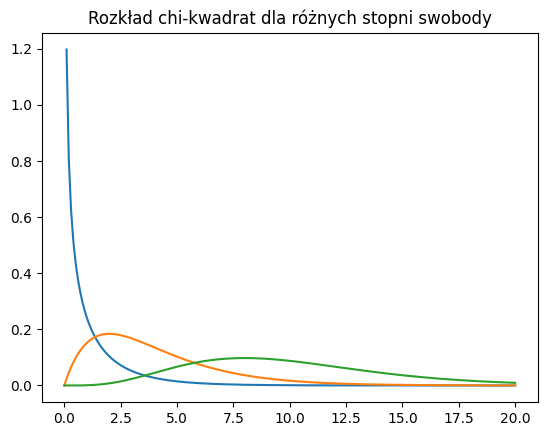

In [103]:
# wizualizacja rozkładu w Pythonie
from scipy.stats import chi2

x = np.linspace(0, 20, 200)

plt.plot(x, chi2.pdf(x, df=1))
plt.plot(x, chi2.pdf(x, df=4))
plt.plot(x, chi2.pdf(x, df=10))

plt.title("Rozkład chi-kwadrat dla różnych stopni swobody")
plt.show()

**Cechy rozkładu chi-kwadrat**

Najważniejsze właściwości:

* wartości są **zawsze dodatnie**
* rozkład jest **asymetryczny (prawostronny)**
* kształt zależy od **liczby stopni swobody**

Im więcej stopni swobody:

* rozkład staje się bardziej **symetryczny**
* zaczyna przypominać rozkład normalny.


Interpretacja:

* **df=1** → bardzo asymetryczny
* **df=10** → bardziej przypomina rozkład normalny.

**Najważniejsze zastosowania**

Rozkład χ² jest podstawą kilku popularnych testów statystycznych:

**Test zgodności**

Chi-Squared Goodness of Fit Test

Sprawdza czy dane pasują do **teoretycznego rozkładu**.

Przykład:

czy kostka jest uczciwa.


**Test niezależności**

Chi-Squared Test of Independence

Sprawdza czy **dwie zmienne kategoryczne są niezależne**.

Przykład:

* płeć
* wybór produktu

---

**Przykład 1 – test uczciwości kostki**

Załóżmy, że rzuciliśmy kostką **60 razy**.

Otrzymane wyniki:

| liczba | liczba wystąpień |
| ------ | ---------------- |
| 1      | 8                |
| 2      | 9                |
| 3      | 10               |
| 4      | 11               |
| 5      | 12               |
| 6      | 10               |

Oczekiwana liczba dla uczciwej kostki:

$60/6 = 10$

In [110]:
from scipy.stats import chisquare

observed = np.array([8,9,10,11,12,10])
expected = np.array([10,10,10,10,10,10])

stat, p = chisquare(observed, expected)

print(stat)
print(p)

1.0
0.9625657732472964


**Interpretacja:**

* **p-value > 0.05** → kostka prawdopodobnie uczciwa
* **p-value < 0.05** → kostka może być nieuczciwa.

---

**Przykład 2 – test niezależności**

Załóżmy dane marketingowe:

|           | Kupuje | Nie kupuje |
| --------- | ------ | ---------- |
| Kobieta   | 40     | 60         |
| Mężczyzna | 30     | 70         |

Pytanie:

> czy płeć wpływa na zakup produktu?

In [111]:
from scipy.stats import chi2_contingency

table = np.array([
    [40, 60],
    [30, 70]
])

chi2, p, dof, expected = chi2_contingency(table)

print("chi2:", chi2)
print("p-value:", p)

chi2: 1.7802197802197803
p-value: 0.18212234100949093


**Interpretacja:**

* **p < 0.05** → zależność istnieje
* **p > 0.05** → brak dowodu zależności.

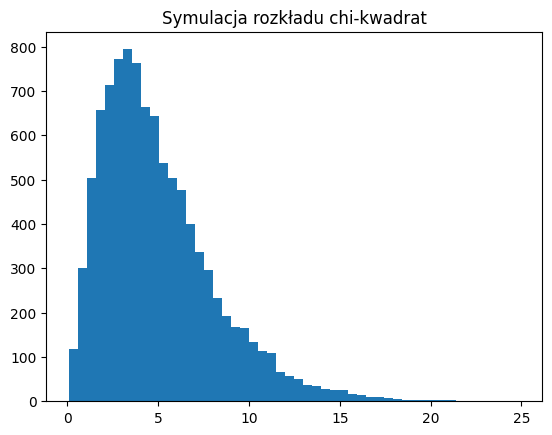

In [107]:
samples = np.random.chisquare(df=5, size=10000)

plt.hist(samples, bins=50)
plt.title("Symulacja rozkładu chi-kwadrat")
plt.show()

**Przykład z Data Science**

Rozkład  jest używany w **selekcji cech** w:

* Machine Learning
* Data Science

np. w modelach klasyfikacji.

Pozwala to wybrać **najbardziej istotne cechy**.

---

**Podsumowanie**

Rozkład $X^2$:

* opisuje **sumę kwadratów zmiennych normalnych**
* zależy od **stopni swobody**
* przyjmuje tylko **dodatnie wartości**

Najważniejsze zastosowania:

* test zgodności
* test niezależności
* analiza wariancji
* selekcja cech w ML

---

**Najważniejsza intuicja**

Rozkład $X^2$ mierzy:

> **jak bardzo dane różnią się od oczekiwanych wartości**

Im większa wartość $X^2$ → tym większa różnica między obserwacją a modelem bazowym (zerowym).

---

Przykładowe wykorzystanie selekcji cech z użyciem pakietu `scikit-learn` (dawne sklearn) oraz zbioru `wine quality` na podstawie rozkładu chi kwadrat.

Korzystamy z `SelectKBest`:
https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html

In [ ]:
!pip install scikit-learn

In [144]:
# wybór cech
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.datasets import load_wine

selector = SelectKBest(chi2, k=5)

# ładowanie danych
# zbiory danych sklearn: https://scikit-learn.org/stable/datasets/toy_dataset.html
X, y = load_wine(return_X_y=True)
X.shape

(178, 13)

In [145]:
import pandas as pd

# lub do ramki pandas
data = load_wine(as_frame=True)
df_wine = pd.DataFrame(data=data.data, columns=data.feature_names)
df_wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [146]:
# a tu jest cecha quality
data.target

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

In [147]:
X_new = SelectKBest(chi2, k=5).fit_transform(df_wine, data.target)
X_new = selector.fit_transform(df_wine, data.target)

In [148]:
X_new.shape

(178, 5)

In [149]:
# które to cechy?
selector.get_feature_names_out(df_wine.columns)

array(['alcalinity_of_ash', 'magnesium', 'flavanoids', 'color_intensity',
       'proline'], dtype=object)

In [150]:
filtered_df = df_wine.loc[:, selector.get_feature_names_out(df_wine.columns)]

In [151]:
filtered_df

,alcalinity_of_ash,magnesium,flavanoids,color_intensity,proline
0,15.6,127.0,3.06,5.64,1065.0
1,11.2,100.0,2.76,4.38,1050.0
2,18.6,101.0,3.24,5.68,1185.0
3,16.8,113.0,3.49,7.80,1480.0
4,21.0,118.0,2.69,4.32,735.0
...,...,...,...,...,...
173,20.5,95.0,0.61,7.70,740.0
174,23.0,102.0,0.75,7.30,750.0
175,20.0,120.0,0.69,10.20,835.0
176,20.0,120.0,0.68,9.30,840.0
